In [ ]:
import pandas as pd
import numpy as np
import torch
import zipfile
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/extracted_images
!cp "/content/drive/MyDrive/Date Scan Converter/Synth Data/output_30k/images_30k.zip" /content/data.zip
!unzip -qo /content/data.zip -d /content/extracted_images
!cp "/content/drive/MyDrive/Date Scan Converter/Synth Data/output_30k/labels_30k_iso.tsv" /content/labels_30k_iso.tsv
!ls /content/extracted_images
!ls -la /content/labels_30k_iso.tsv

cp: cannot stat '/content/drive/MyDrive/Date Scan Converter/Synth Data/output_30k/images_30k.zip': No such file or directory
unzip:  cannot find or open /content/data.zip, /content/data.zip.zip or /content/data.zip.ZIP.
cp: cannot stat '/content/drive/MyDrive/Date Scan Converter/Synth Data/output_30k/labels_30k_iso.tsv': No such file or directory
ls: cannot access '/content/labels_30k_iso.tsv': No such file or directory


In [ ]:
# ============================================================
# 1) INSTALL DEPENDENCIES (Colab)
# ============================================================
!pip -q install pillow requests numpy torch torchvision

In [ ]:
# ============================================================
# 2) IMPORTS + GLOBAL SETTINGS
# ============================================================

import os
import csv
import json
import random
import requests
from dataclasses import dataclass
from datetime import date, timedelta, datetime
from typing import List, Tuple, Dict

import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Seed everything for reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection: use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PROJECT_ROOT = "/content/extracted_images"
print("Project root:", PROJECT_ROOT)

Using device: cuda
Project root: /content/extracted_images


In [ ]:
import os

# Saving to /content/ is fast but wiped when Colab restarts.
CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

Checkpoints will be saved to: /content/checkpoints


In [ ]:
import math
from collections import defaultdict

# ============================================================
# 3) DATASET + VOCAB + CTC COLLATE
# ------------------------------------------------------------
# Word-level vocabulary: predicts whole tokens like "January",
# "Mar", "01", "2023" instead of one character at a time.
# ============================================================

@dataclass
class OCRRecord:
    image_path: str
    text: str


class OCRWordVocabulary:
    """Maps word-level tokens <-> integer IDs for model training."""

    TOKENS = [
        # Full month names
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
        # Month abbreviations
        "Jan", "Feb", "Mar", "Apr", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec",
        # Common separators / punctuation
        "/", "-", ".", ",", "'", " ",
        # Zero-padded day/month numbers  "01" .. "31"
        *[f"{i:02d}" for i in range(1, 32)],
        # Bare day/month numbers  "1" .. "31"
        *[str(i) for i in range(1, 32)],
        # Four-digit years  1900 .. 2099
        *[str(y) for y in range(1900, 2100)],
        # Two-digit years  "00" .. "99"
        *[f"{y:02d}" for y in range(0, 100)],
    ]

    def __init__(self):
        self.blank_idx = 0

        seen: set = set()
        unique: List[str] = []
        for t in self.TOKENS:
            if t not in seen:
                seen.add(t)
                unique.append(t)
        self.tokens = unique

        self.token_to_idx: Dict[str, int] = {t: i + 1 for i, t in enumerate(self.tokens)}
        self.idx_to_char:  Dict[int, str] = {i + 1: t for i, t in enumerate(self.tokens)}
        self.idx_to_token = self.idx_to_char

        self.characters = self.tokens

    @property
    def num_classes(self) -> int:
        return len(self.tokens) + 1

    def tokenize(self, text: str) -> List[str]:
        import re
        return re.findall(r"[A-Za-z]+|[\d]+|[\/\-\.,\' ]", text)

    def encode(self, text: str) -> List[int]:
        tokens = self.tokenize(text)
        result = []
        for tok in tokens:
            if tok not in self.token_to_idx:
                raise ValueError(
                    f"Unknown token '{tok}' in '{text}'. "
                    "Add it to OCRWordVocabulary.TOKENS if needed."
                )
            result.append(self.token_to_idx[tok])
        return result

    def decode(self, indices: List[int]) -> str:
        return "".join(
            self.idx_to_token[i] for i in indices if i in self.idx_to_token
        )


# Backward-compatible alias
OCRVocabulary = OCRWordVocabulary


class HandwrittenDateDataset(Dataset):
    """PyTorch dataset reading image + text label pairs."""
    def __init__(self, records, vocab, image_height=64, image_width=320, augment=False):
        self.records = records
        self.vocab = vocab

        pil_transforms = [
          transforms.Resize((image_height, image_width))
        ]

        if augment:
            pil_transforms.extend([
                transforms.RandomAffine(
                    degrees=8,
                    translate=(0.1, 0.1),
                    scale=(0.8, 1.2),
                    shear=8
                ),
                transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
            ])

        tensor_transforms = [
            transforms.ToTensor(),
        ]

        if augment:
            tensor_transforms.extend([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
                transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
                transforms.ColorJitter(brightness=0.3, contrast=0.3),
                transforms.RandomErasing(p=0.2, scale=(0.01, 0.1)),
            ])

        tensor_transforms.append(transforms.Normalize(mean=(0.5,), std=(0.5,)))

        self.transforms = transforms.Compose(pil_transforms + tensor_transforms)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        with Image.open(record.image_path) as img:
          img = img.convert("L")
          image_tensor = self.transforms(img)

        target_ids = torch.tensor(self.vocab.encode(record.text), dtype=torch.long)
        return image_tensor, target_ids, record.text, record.image_path


def load_records(labels_tsv: str, images_dir: str) -> List[OCRRecord]:
    records = []
    with open(labels_tsv, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            path = os.path.join(images_dir, row["filename"])
            if os.path.exists(path):
                records.append(OCRRecord(image_path=path, text=row["date_string"]))

    if not records:
        raise ValueError("No records found. Check labels path and images folder.")
    return records


def split_records(records, val_ratio=0.1, test_ratio=0.1, seed=42):
    records = list(records)
    random.Random(seed).shuffle(records)

    n = len(records)
    n_test = int(n * test_ratio)
    n_val = int(n * val_ratio)
    n_train = n - n_val - n_test

    train_records = records[:n_train]
    val_records = records[n_train:n_train+n_val]
    test_records = records[n_train+n_val:]
    return train_records, val_records, test_records


def build_vocab_from_records(records: List[OCRRecord]) -> OCRWordVocabulary:
    """Build (and validate) the fixed word-level vocabulary against all records."""
    vocab = OCRWordVocabulary()
    bad = 0
    for r in records:
        try:
            vocab.encode(r.text)
        except ValueError as e:
            print(f"Warning - skipping unrepresentable label: {e}")
            bad += 1
    if bad:
        print(f"  ({bad} records have unknown tokens and will error during training)")
    print(f"Word vocabulary: {len(vocab.tokens)} tokens (+ 1 CTC blank = {vocab.num_classes} classes)")
    return vocab


def ctc_collate_fn(batch):
    """Batch format for CTC. Now also returns image_paths."""
    images, targets, texts, image_paths = zip(*batch)
    images = torch.stack(images, dim=0)
    target_lengths = torch.tensor([len(t) for t in targets], dtype=torch.long)
    flat_targets = torch.cat(targets, dim=0)
    return images, flat_targets, target_lengths, list(texts), list(image_paths)

In [ ]:
import os

LABELS_PATH = '/content/labels_30k_iso.tsv'
IMAGES_DIR = '/content/extracted_images/images_30k'

if os.path.exists(LABELS_PATH):
    all_records = load_records(LABELS_PATH, IMAGES_DIR)
    vocab = build_vocab_from_records(all_records)
    print(f"Vocabulary built with {len(vocab.characters)} characters: {vocab.characters}")

    train_recs, val_recs, test_recs = split_records(all_records)

    train_ds = HandwrittenDateDataset(train_recs, vocab, augment=True)

    img_t, label_t, raw_text, img_path = train_ds[0]
    print(f"Sample Loaded: {raw_text}")
    print(f"Image Tensor Shape: {img_t.shape}")
else:
    print(f"Warning: {LABELS_PATH} not found. Please ensure your labels.tsv is in the extracted folder.")

Word vocabulary: 338 tokens (+ 1 CTC blank = 339 classes)
Vocabulary built with 338 characters: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'Jan', 'Feb', 'Mar', 'Apr', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '/', '-', '.', ',', "'", ' ', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '1', '2', '3', '4', '5', '6', '7', '8', '9', '1900', '1901', '1902', '1903', '1904', '1905', '1906', '1907', '1908', '1909', '1910', '1911', '1912', '1913', '1914', '1915', '1916', '1917', '1918', '1919', '1920', '1921', '1922', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1931', '1932', '1933', '1934', '1935', '1936', '1937', '1938', '1939', '1940', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954', '19

In [ ]:
import math
from collections import defaultdict

# ============================================================
# 6) CRNN MODEL (CNN + BiLSTM + CTC) with BATCH NORM + DROPOUT
# ============================================================

class CRNN(nn.Module):
    def __init__(self, num_classes, input_channels=1, cnn_out_channels=256, lstm_hidden_size=256, lstm_layers=2):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, cnn_out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
        )

        lstm_input_size = cnn_out_channels * 8

        self.rnn = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            bidirectional=True,
            batch_first=False,
            dropout=0.3 if lstm_layers > 1 else 0.0,
        )

        self.pre_classifier_dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(lstm_hidden_size * 2, num_classes)

    def forward(self, x):
        assert x.ndim == 4, f"Expected [B, C, H, W], got {x.shape}"
        assert x.shape[1] == 1, f"Expected 1 channel grayscale image, got {x.shape}"

        features = self.cnn(x)
        b, c, h, w = features.shape

        features = features.permute(3, 0, 1, 2).contiguous().view(w, b, c * h)

        recurrent, _ = self.rnn(features)
        recurrent = self.pre_classifier_dropout(recurrent)
        logits = self.classifier(recurrent)
        log_probs = F.log_softmax(logits, dim=2)
        return log_probs


def greedy_decode(log_probs, blank_idx=0):
    """CTC greedy decoding."""
    best = torch.argmax(log_probs, dim=2)
    best = best.permute(1, 0).cpu().tolist()

    decoded_batch = []
    for seq in best:
        collapsed = []
        prev = None
        for idx in seq:
            if idx != blank_idx and idx != prev:
                collapsed.append(idx)
            prev = idx
        decoded_batch.append(collapsed)

    return decoded_batch


def log_sum_exp(a, b):
    if a == -float("inf"): return b
    if b == -float("inf"): return a
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))


def ctc_beam_search_decode(log_probs, beam_width=10, blank_idx=0):
    T, B, C = log_probs.shape
    log_probs = log_probs.detach().cpu()
    decoded_batch = []

    for b in range(B):
        beams = {(): 0.0}
        for t in range(T):
            new_beams = defaultdict(lambda: -float("inf"))
            for prefix, score in beams.items():
                for c in range(C):
                    p = log_probs[t, b, c].item()
                    if c == blank_idx:
                        new_prefix = prefix
                    else:
                        if len(prefix) > 0 and prefix[-1] == c:
                            new_prefix = prefix
                        else:
                            new_prefix = prefix + (c,)
                    new_beams[new_prefix] = log_sum_exp(new_beams[new_prefix], score + p)
            beams = dict(sorted(new_beams.items(), key=lambda x: x[1], reverse=True)[:beam_width])
        best_seq = max(beams.items(), key=lambda x: x[1])[0]
        decoded_batch.append(list(best_seq))
    return decoded_batch

In [ ]:
import math
from collections import defaultdict

# ============================================================
# 7) TRAINING UTILITIES + TRAIN LOOP
# ============================================================

def text_exact_match(pred_texts, gt_texts):
    return sum(int(p == g) for p, g in zip(pred_texts, gt_texts)) / max(1, len(gt_texts))


def edit_distance(a: str, b: str) -> int:
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a) + 1):
        dp[i][0] = i
    for j in range(len(b) + 1):
        dp[0][j] = j

    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )
    return dp[-1][-1]


def char_error_rate(pred_texts, gt_texts):
    edits = 0
    chars = 0
    for p, g in zip(pred_texts, gt_texts):
        edits += edit_distance(p, g)
        chars += len(g)
    return edits / max(1, chars)


def run_epoch(model, loader, criterion, optimizer, idx_to_char, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_pred_texts = []
    all_gt_texts = []
    mispredicted_image_paths = []

    for images, flat_targets, target_lengths, gt_texts, image_paths in loader:
        images = images.to(DEVICE)
        flat_targets = flat_targets.to(DEVICE)
        target_lengths = target_lengths.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            log_probs = model(images)

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=log_probs.size(0),
                dtype=torch.long,
                device=DEVICE,
            )

            loss = criterion(log_probs, flat_targets, input_lengths, target_lengths)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

        total_loss += loss.item() * images.size(0)

        pred_ids = greedy_decode(log_probs.detach(), blank_idx=0)
        pred_texts = ["".join(idx_to_char[i] for i in seq if i in idx_to_char) for seq in pred_ids]

        for i in range(len(pred_texts)):
            if pred_texts[i] != gt_texts[i]:
                mispredicted_image_paths.append(image_paths[i])

        all_pred_texts.extend(pred_texts)
        all_gt_texts.extend(gt_texts)

    avg_loss = total_loss / max(1, len(loader.dataset))
    em = text_exact_match(all_pred_texts, all_gt_texts)
    cer = char_error_rate(all_pred_texts, all_gt_texts)
    return avg_loss, em, cer, mispredicted_image_paths


def train_model(
    labels_path=LABELS_PATH,
    images_dir=IMAGES_DIR,
    epochs=15,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-5,
    num_workers=2,
):
    records = load_records(labels_path, images_dir)
    train_records, val_records, test_records = split_records(records, val_ratio=0.1, test_ratio=0.1, seed=SEED)

    vocab = build_vocab_from_records(train_records)

    train_ds = HandwrittenDateDataset(train_records, vocab, augment=True)
    val_ds = HandwrittenDateDataset(val_records, vocab, augment=False)
    test_ds = HandwrittenDateDataset(test_records, vocab, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=ctc_collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=ctc_collate_fn)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=ctc_collate_fn)

    model = CRNN(num_classes=vocab.num_classes).to(DEVICE)
    criterion = nn.CTCLoss(blank=0, zero_infinity=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    best_val_cer = float("inf")
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, "best_crnn.pt")

    print(f"Train/Val/Test sizes: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    print(f"Vocabulary ({len(vocab.characters)} chars): {vocab.characters}")

    for epoch in range(1, epochs + 1):
        tr_loss, tr_em, tr_cer, _ = run_epoch(model, train_loader, criterion, optimizer, vocab.idx_to_char, train=True)
        va_loss, va_em, va_cer, _ = run_epoch(model, val_loader, criterion, optimizer, vocab.idx_to_char, train=False)

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train_loss={tr_loss:.4f} train_em={tr_em:.4f} train_cer={tr_cer:.4f} | "
            f"val_loss={va_loss:.4f} val_em={va_em:.4f} val_cer={va_cer:.4f}"
        )

        scheduler.step(va_cer)

        if va_cer < best_val_cer:
            best_val_cer = va_cer
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "vocab_chars": vocab.characters,
                    "image_height": 64,
                    "image_width": 320,
                },
                best_ckpt_path,
            )
            print("Saved best checkpoint:", best_ckpt_path)

    checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    te_loss, te_em, te_cer, mispredicted_test_images = run_epoch(model, test_loader, criterion, optimizer, vocab.idx_to_char, train=False)
    print(f"Test metrics | loss={te_loss:.4f} em={te_em:.4f} cer={te_cer:.4f}")
    print(f"Mispredicted test images: {len(mispredicted_test_images)} total")

    mispredicted_images_path_file = os.path.join(CHECKPOINT_DIR, "mispredicted_images.txt")
    with open(mispredicted_images_path_file, "w", encoding="utf-8") as f:
        for img_path in mispredicted_test_images:
            f.write(img_path + "\n")
    print(f"Saved mispredicted image paths to: {mispredicted_images_path_file}")

    metrics_path = os.path.join(CHECKPOINT_DIR, "final_metrics.json")
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump({"test_loss": te_loss, "test_exact_match": te_em, "test_cer": te_cer}, f, indent=2)

    print("Saved metrics:", metrics_path)
    return best_ckpt_path

In [ ]:
# ============================================================
# 8) START TRAINING
# ============================================================

best_checkpoint = train_model(
    labels_path=LABELS_PATH,
    images_dir=IMAGES_DIR,
    epochs=100,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    num_workers=2,
)

print("Best checkpoint path:", best_checkpoint)

Word vocabulary: 338 tokens (+ 1 CTC blank = 339 classes)
Train/Val/Test sizes: 24000/3000/3000
Vocabulary (338 chars): ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'Jan', 'Feb', 'Mar', 'Apr', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '/', '-', '.', ',', "'", ' ', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '1', '2', '3', '4', '5', '6', '7', '8', '9', '1900', '1901', '1902', '1903', '1904', '1905', '1906', '1907', '1908', '1909', '1910', '1911', '1912', '1913', '1914', '1915', '1916', '1917', '1918', '1919', '1920', '1921', '1922', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1931', '1932', '1933', '1934', '1935', '1936', '1937', '1938', '1939', '1940', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '19

In [ ]:
!mkdir -p "/content/drive/MyDrive/Date Scan Converter/Trained Models"
!cp /content/checkpoints/best_crnn.pt "/content/drive/MyDrive/Date Scan Converter/Trained Models/crnn_30k_75ep.pt"
!cp /content/checkpoints/final_metrics.json "/content/drive/MyDrive/Date Scan Converter/Trained Models/crnn_30k_75ep_metrics.json"
!cp /content/checkpoints/mispredicted_images.txt "/content/drive/MyDrive/Date Scan Converter/Trained Models/crnn_30k_75ep_misses.txt"
!ls -la "/content/drive/MyDrive/Date Scan Converter/Trained Models/"

total 192932
-rw------- 1 root root 29149520 May 28 03:16  best_crnn_30k_20k.pt
-rw------- 1 root root 26782871 May 21 18:31  best_crnn_avery_1.pt
-rw------- 1 root root 29149456 May 22 03:29  best_crnn_avery_30k.pt
-rw------- 1 root root 26782871 May 21 19:06 'best_crnn _lucinda_3(50 epoch).pt'
-rw------- 1 root root 26782871 May 21 03:48 'best_crnn_lucinda3(supa goated one).pt'
-rw------- 1 root root      105 May 29 23:57  crnn_30k_75ep_metrics.json
-rw------- 1 root root      576 May 29 23:57  crnn_30k_75ep_misses.txt
-rw------- 1 root root 29761488 May 29 23:57  crnn_30k_75ep.pt
-rw------- 1 root root 29149584 May 28 06:09  crnn_built-in_augment_and_dropout_rate.pt


In [ ]:
!cat /content/checkpoints/final_metrics.json

{
  "test_loss": 0.003233087094966322,
  "test_exact_match": 0.996,
  "test_cer": 0.0004765384248816596
}

In [ ]:
print(best_checkpoint)

/content/checkpoints/best_crnn.pt


In [ ]:
import random
from IPython.display import Image as IPImage, display
import os

mispredicted_images_path_file = os.path.join(CHECKPOINT_DIR, "mispredicted_images.txt")

mispredicted_test_images = []
if os.path.exists(mispredicted_images_path_file):
    with open(mispredicted_images_path_file, "r", encoding="utf-8") as f:
        mispredicted_test_images = [line.strip() for line in f if line.strip()]
    print(f"Loaded {len(mispredicted_test_images)} mispredicted image paths.")
else:
    print(f"Warning: Mispredicted images file not found at {mispredicted_images_path_file}.")

if mispredicted_test_images:
    num_images_to_display = min(5, len(mispredicted_test_images))
    random_subset_paths = random.sample(mispredicted_test_images, num_images_to_display)

    print(f"\nDisplaying a random subset of {num_images_to_display} mispredicted images:")
    for img_path in random_subset_paths:
        display(IPImage(filename=img_path))
        print(f"Image Path: {img_path}\n")
else:
    print("No mispredicted images found to display.")

Input Image:


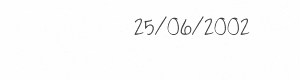

Image path: /content/extracted_images/images_30k/000000.png
Raw prediction (word tokens): 25/06/2002
Normalized YYYY-MM-DD: 2002-06-25


In [ ]:
import cv2
from google.colab.patches import cv2_imshow

DATE_PATTERNS = [
    "%m/%d/%Y", "%m/%d/%y", "%d/%m/%Y", "%d/%m/%y",
    "%B %d, %Y", "%d %B %Y", "%d %b %Y", "%b %d, %Y",
    "%m-%d-%Y", "%d-%m-%Y", "%m.%d.%Y", "%Y-%m-%d", "%d %b '%y",
]

def normalize_date_string(text: str):
    text = " ".join(text.strip().split())
    for pattern in DATE_PATTERNS:
        try:
            parsed = datetime.strptime(text, pattern)
            return parsed.strftime("%Y-%m-%d")
        except ValueError:
            continue
    return None

def tokens_to_date_string(decoded: str) -> str:
    return decoded.strip()


def predict_single_image(checkpoint_path: str, image_path: str):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    vocab = OCRWordVocabulary()

    saved_tokens = checkpoint.get("vocab_chars", None)
    if saved_tokens is not None and len(saved_tokens) != len(vocab.tokens):
        print("Warning: checkpoint vocab size doesn't match current word vocab. "
              "Re-train the model with the new word-level vocabulary.")

    model = CRNN(num_classes=vocab.num_classes).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    tfm = transforms.Compose([
        transforms.Resize((checkpoint["image_height"], checkpoint["image_width"])),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,)),
    ])

    with Image.open(image_path) as img:
        img = img.convert("L")
        x = tfm(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        log_probs = model(x)
        pred_ids = greedy_decode(log_probs, blank_idx=0)[0]

    raw_text = tokens_to_date_string(vocab.decode(pred_ids))
    normalized = normalize_date_string(raw_text)

    print("Input Image:")
    cv2_imshow(np.array(img))

    print("Image path:", image_path)
    print("Raw prediction (word tokens):", raw_text)
    print("Normalized YYYY-MM-DD:", normalized if normalized else "N/A")

# Test on a sample from your dataset
sample_image = all_records[0].image_path
predict_single_image(best_checkpoint, sample_image)

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    with open(f'/content/{fn}', 'wb') as f:
        f.write(uploaded[fn])
    user_image_path = f'/content/{fn}'
    break

if 'user_image_path' in locals():
    print(f'Uploaded image saved to: {user_image_path}')
else:
    print('No image was uploaded.')

Saving tst1.jpg to tst1.jpg
User uploaded file "tst1.jpg"
Uploaded image saved to: /content/tst1.jpg


Input Image:


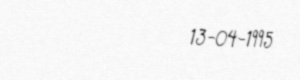

Image path: /content/tst1.jpg
Raw prediction (word tokens): 13-04-1995
Normalized YYYY-MM-DD: 1995-04-13


In [ ]:
if 'user_image_path' in locals() and os.path.exists(user_image_path):
    predict_single_image(best_checkpoint, user_image_path)
else:
    print("Please upload an image in the previous cell first.")

In [ ]:
import torch

sample_image = all_records[0].image_path

checkpoint_path = '/content/checkpoints/best_crnn.pt'

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    restored_vocab = OCRWordVocabulary()
    print(f"Word vocabulary: {len(restored_vocab.tokens)} tokens "
          f"(+ 1 CTC blank = {restored_vocab.num_classes} classes).")

    restored_model = CRNN(num_classes=restored_vocab.num_classes).to(DEVICE)
    restored_model.load_state_dict(checkpoint['model_state_dict'])
    restored_model.eval()

    print("Model successfully restored and set to evaluation mode.")
else:
    print(f"Error: Checkpoint not found at {checkpoint_path}")


tfm = transforms.Compose([
        transforms.Resize((checkpoint["image_height"], checkpoint["image_width"])),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,)),
    ])

with Image.open(sample_image) as img:
    img = img.convert("L")
    x = tfm(img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    log_probs = restored_model(x)
    pred_ids = greedy_decode(log_probs, blank_idx=0)[0]

raw_text = tokens_to_date_string(restored_vocab.decode(pred_ids))
normalized = normalize_date_string(raw_text)

cv2_imshow(np.array(img))

print("Image path:", sample_image)
print("Raw prediction (word tokens):", raw_text)
print("Normalized YYYY-MM-DD:", normalized if normalized else "N/A")